# The Iris Dataset 


## 1. Introduction

We analyze the classical Iris dataset, which consists of measurements of Iris flowers gathered by E. Anderson and first studied by R. A. Fisher. 
The dataset contains measurements (in cm) of 4 characteristics, namely the sepal length, sepal width, petal length, and petal width, for 50 flowers of each iris plant type, Iris Setosa, Iris Virginica, and Iris Versicolor. The problem at hand is to successfully infer the plant type (class) of each flower from the given data. The data is obtained from the [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/53/iris). 

The data is first imported and preprocessed, after which some EDA is applied to identify the most useful characteristics in order to perform classification. Several classical classification algorithms are employed, which are in turn optimized in terms of their hyperparameters. Finally their performance is evaluated and visually presented, and a final comparison between all algorithms is made. 


## 2. Importing and Preprocessing  

In [107]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import time
from functools import wraps
from functools import lru_cache

### Import data analysis tools
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn import preprocessing as prep
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, classification_report, confusion_matrix
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest




### Import Classifiers
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

We import the data and cache it to avoid reloading it multiple times while running the classification models.

In [108]:
### column names and class mappings
columns = ['Sepal Length','Sepal Width','Petal Length','Petal Width','Class']
classes = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica':2}

data_location = "iris/iris.data"

@lru_cache(maxsize=1)
def load_data(csv_path: str = data_location) -> pd.DataFrame:
    print("Loading data from CSV")
    df = pd.read_csv(csv_path, names=columns, header = None)
    df['Class'] = df['Class'].map(classes)
    return df

### Load data into dataframe
df = load_data()

Loading data from CSV


We present some basic information on the dataset.

In [109]:
### Print first rows of dataframe to verify dataframe was loaded properly
print(df.head())

   Sepal Length  Sepal Width  Petal Length  Petal Width  Class
0           5.1          3.5           1.4          0.2      0
1           4.9          3.0           1.4          0.2      0
2           4.7          3.2           1.3          0.2      0
3           4.6          3.1           1.5          0.2      0
4           5.0          3.6           1.4          0.2      0


In [110]:
### Print basic information 
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal Length  150 non-null    float64
 1   Sepal Width   150 non-null    float64
 2   Petal Length  150 non-null    float64
 3   Petal Width   150 non-null    float64
 4   Class         150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


From the above info we can verify that the data contains no missing values. According to the dataset information available on [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/53/iris) there are two incorrect entries. This can be verified using the original dataset reported in [R.A.Fisher's article](https://onlinelibrary.wiley.com/doi/10.1111/j.1469-1809.1936.tb02137.x). We replace the wrong measurements. These corrections are applied prior to splitting as they are based on external domain knowledge and not inferred from the dataset itself.

In [111]:
### Correct measurements, the first corresponding to the 35th entry, the second to the 38th entry.
data_point_1 = [4.9,3.1,1.5,0.2,np.int64(0)]
data_point_2 = [4.9,3.6,1.4,0.1,np.int64(0)]

### Replace the entries
df.loc[34] = data_point_1
df.loc[37] = data_point_2

### Print the rows to verify
print(df.loc[34])
print('------')
print(df.loc[37])


Sepal Length    4.9
Sepal Width     3.1
Petal Length    1.5
Petal Width     0.2
Class           0.0
Name: 34, dtype: float64
------
Sepal Length    4.9
Sepal Width     3.6
Petal Length    1.4
Petal Width     0.1
Class           0.0
Name: 37, dtype: float64


We check whether the dataset is balanced.

In [112]:
df['Class'].value_counts()

Class
0    50
1    50
2    50
Name: count, dtype: int64

We check whether there are duplicates in the dataset.

In [113]:
### Print number of duplicate entries
print(df.duplicated().sum())

### Print duplicate entries
df[df.duplicated()]

1


,Sepal Length,Sepal Width,Petal Length,Petal Width,Class
142,5.8,2.7,5.1,1.9,2


Since there is only one duplicate entry we may assume that it is a genuine observation, and not some systematic mistake.

## 3. Exploratory Data Analysis and Feature Selection

We proceed to present basic descriptive statistics of the data, and visualize scatter plots and histograms of the features.

In [114]:
### Print basic statistics
df.describe()

,Sepal Length,Sepal Width,Petal Length,Petal Width,Class
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


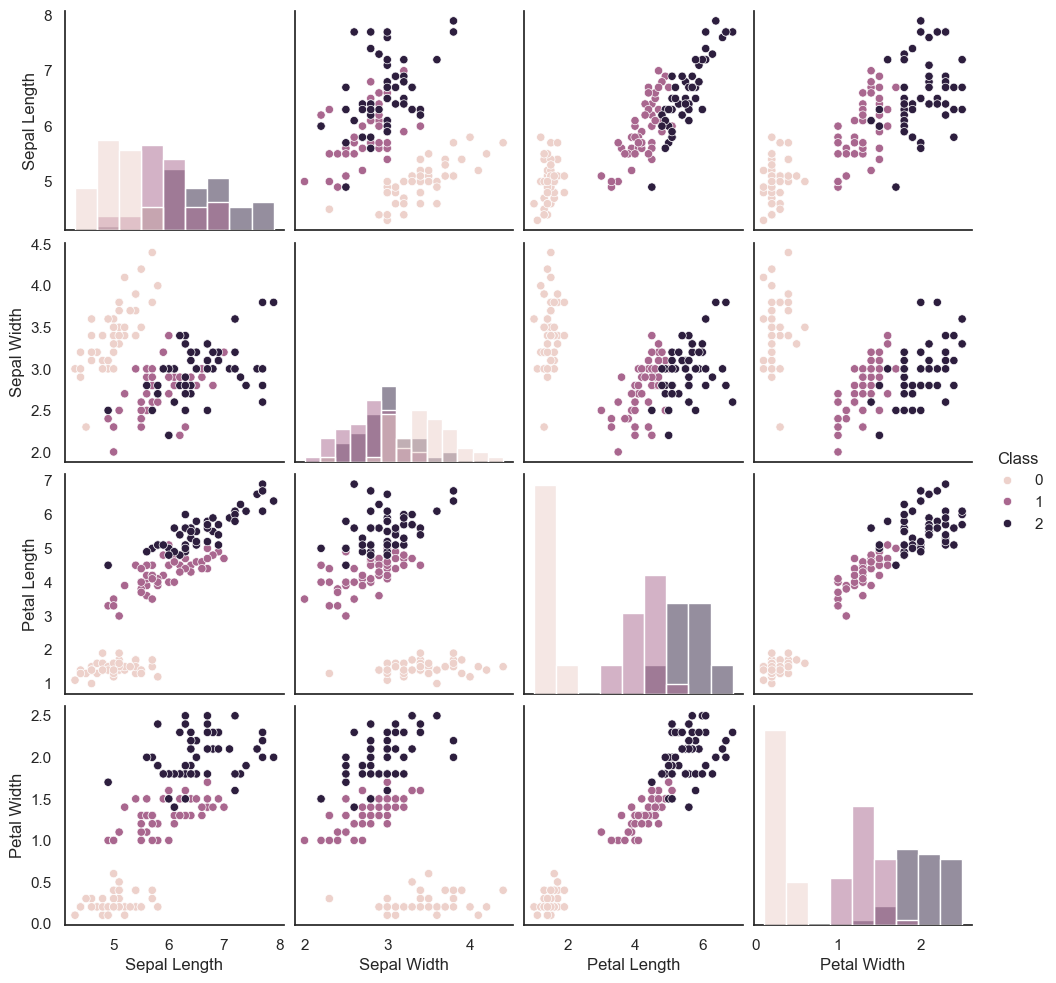

In [115]:
### Scatter plots of everything
sns.pairplot(df, hue = 'Class', diag_kind = 'hist')
plt.show()

It is clear from the above plot that Iris Setosa (Class 0) can be separated from Iris Virginica and Versicolor by a linear function.

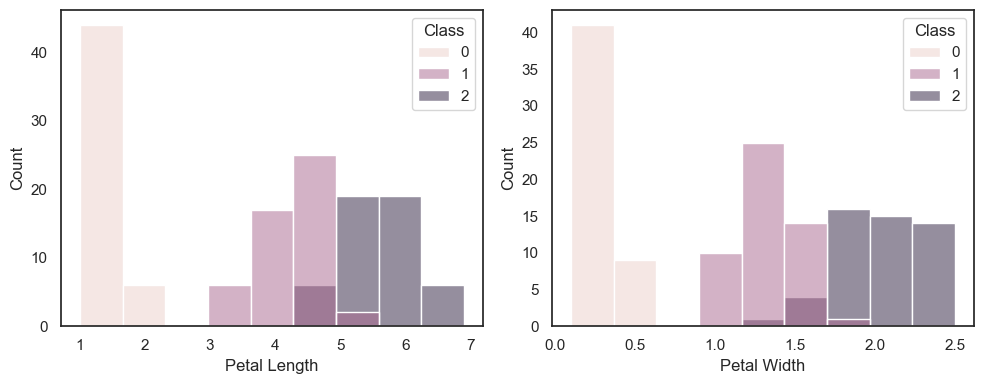

In [116]:
### Plot histograms of Petal Length and Width separately
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df, x = 'Petal Length', hue = 'Class', ax=axes[0])
sns.histplot(df, x = 'Petal Width', hue = 'Class', ax=axes[1])

plt.tight_layout()
plt.show()

As can be seen above, Iris Setosa has consistently smaller Petal Length and Width compared to Iris Virginica and Versicolor. This indicates that Petal Length and Width are more informative characteristics to distinguish between the classes than Sepal Length and Width. As we will proceed with feature selection we split the data into Training and Test sets.We stratify the data with respect to class in order to keep the proportion of each flower type the same across training and testing set. The test set will be 20% of the total data. Since the splitting is random, a random state is chosen to ensure reproducibility.


In [117]:
### Split data
X = df[['Sepal Length','Sepal Width','Petal Length','Petal Width']]
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state = 123)

In [118]:
chi_scores, p_values = chi2(X_train, y_train)

results = pd.DataFrame({
    'feature': X.columns,
    'chi2_score': chi_scores,
    'p_value': p_values
}).sort_values(by='chi2_score', ascending=False)

print(results)



        feature  chi2_score       p_value
2  Petal Length   91.365681  1.446087e-20
3   Petal Width   53.430726  2.498419e-12
0  Sepal Length    7.980561  1.849452e-02
1   Sepal Width    3.067340  2.157425e-01


As can be seen the features ranked best in terms of the Chi-squared statistic are indeed Petal Length and Petal Width, thus we will perform our classification task only using those two characteristics. This has two advantages, namely it reduces dimensionality, and aids visualization. We apply this with a standard feature selection method:

In [119]:
### Select 2 best features
selector = SelectKBest(chi2, k=2)
X_train_new = selector.fit_transform(X_train, y_train)
selected_features = X_train.columns[selector.get_support()]

### Pass data into a dataframe
X_train = pd.DataFrame(X_train_new, columns=selected_features)

### Apply same transformation to test dataset
X_test = X_test[selected_features]


## 4. Modeling

We apply classical classification algorithms on the training data and assess each algorithm's performance with the help of standard metrics. The algorithms used are the following:

- [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) (K Nearest Neighbors)
- [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) (Support Vector Machine)
- [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (Logistic Regression)
- [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) (Random Forest)
- [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier) (Neural Network)
- [XGBClassifier](https://xgboost.readthedocs.io/en/release_3.2.0/index.html) (Tree method with Gradient boosting)

We additionally use a dummy classifier that predicts labels at random. Although this classifier usually scores really low it serves as a benchmark for comparing scores.

- [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (Dummy)

For each model a scaler is optionally applied and a set of tuning parameters (hyperparameters) are defined. The optimal parameters are chosen via 10-fold Cross Validation. 
After optimal parameters are chosen the model is retrained on the whole training data and tested on the test data.  


## 4.1. Preliminaries 

We define two functions to aid in visualizing the model performance. The first function displays the decision boundary of a trained model along with a scatter plot of the test set on this boundary. The second function displays the confusion matrix of a trained model applied on the test set.

In [120]:
### Draw the decision boundary of a classifier
def DrawDecisionBoundary(classifier, X_test, y_test):

    ### Define the labels to be displayed in the legend
    label_map = {
    0: 'Setosa',
    1: 'Virginica',
    2: 'Versicolor'
    }
    y_test = y_test.map(label_map)
    
    ### Assign labels to the classes 
    cmap = plt.cm.coolwarm
    colors = [cmap(i / 2) for i in range(3)]
    palette = dict(zip([label_map[c] for c in classifier.classes_], colors))

    ### Set the style of the plot
    sns.set_theme(style="white") 
    fig, ax = plt.subplots(figsize=(8, 6))

    ### Plot decision boundary
    disp = DecisionBoundaryDisplay.from_estimator(classifier, X_test, response_method='predict', cmap='coolwarm', alpha=0.4, ax=ax)

    ### Plot test points 
    sns.scatterplot(x=X_test.iloc[:,0], y=X_test.iloc[:,1], hue=y_test, palette=palette, edgecolor='black', s=60, ax=ax)

    ### Add labels and titles 
    sns.despine()
    clf_name = classifier.steps[-1][1].__class__.__name__
    ax.set_title(f'{clf_name} Decision Boundary')
    ax.set_xlabel(f'{X_test.columns[0]}')
    ax.set_ylabel(f'{X_test.columns[1]}')   


    ### Save figure (Optional)
    #plt.savefig(f'{clf_name} Decision Boundary', bbox_inches='tight')

    plt.show()

In [121]:
### Display the confusion matrix 
def ConfusionMatrix(classifier, X_test, y_test):

    ### Define class labels and classifier name
    clf_name = classifier.steps[-1][1].__class__.__name__
    class_names = ['Setosa', 'Virginica', 'Versicolor']

    ### Predict labels of test set
    y_pred = classifier.predict(X_test)

    ### Calculate confusion matrix
    matrix = confusion_matrix(y_test, y_pred)

    ### Plot confusion matrix
    sns.heatmap(matrix, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)

    ### Add labels and title
    plt.title(f'{clf_name} Confusion Matrix')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    ### Save figure (Optional)
    #plt.savefig(f'{clf_name} Confusion Matrix', bbox_inches='tight')
    
    plt.show()

In [122]:
### Define scalers that will be applied to the data
scalers = ['passthrough', prep.StandardScaler(), prep.MinMaxScaler(), prep.RobustScaler()]

In [123]:
### Define a dataframe to keep track of each model's accuracy and precision
scores = pd.DataFrame(columns=['Model', 'CV Accuracy', 'Accuracy', 'Precision', 'F1 score', 'Recall'])

## 4.2. Classification

### 4.2.0. DummyClassifier

The dummy classifier predicts a random label respecting class distribution. It serves as a benchmark model to compare metrics to.

In [124]:
### Define pipeline. Includes scaling and model training
pipe_dummy = Pipeline([
        ('scaler', 'passthrough'),
        ('model', DummyClassifier(strategy = 'stratified'))
    ])

In [125]:
### Model training
start_time = time.time()
clf_dummy = pipe_dummy
clf_dummy.fit(X_train, y_train)
print(f'Training took {time.time()-start_time:.2f} seconds')

Training took 0.00 seconds


In [126]:
### Predict labels
y_pred_dummy = clf_dummy.predict(X_test)

### Add model's metrics to dataframe
name = f"{clf_dummy.steps[-1][1].__class__.__name__} ({clf_dummy.steps[-1][1].strategy})"
cv_accuracy = 'Not Applicable'
accuracy = accuracy_score(y_test, y_pred_dummy)
precision = precision_score(y_test, y_pred_dummy, average = 'weighted')
f1 = f1_score(y_test, y_pred_dummy, average = 'weighted')
recall = recall_score(y_test, y_pred_dummy, average = 'weighted')
scores.loc[len(scores)] = [name, cv_accuracy, accuracy, precision, f1, recall]

### Display evaluation metrics
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_dummy))

Test Accuracy: 0.23333333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.18      0.20      0.19        10
           1       0.36      0.40      0.38        10
           2       0.12      0.10      0.11        10

    accuracy                           0.23        30
   macro avg       0.22      0.23      0.23        30
weighted avg       0.22      0.23      0.23        30



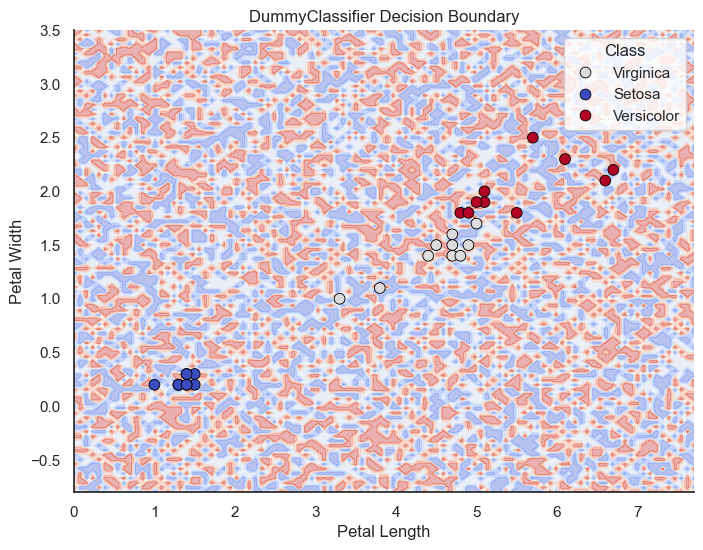

In [127]:
### Draw the decision boundary for the trained classifier
DrawDecisionBoundary(clf_dummy, X_test, y_test)

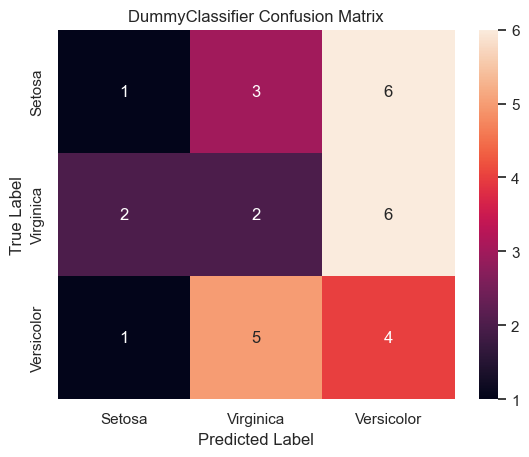

In [128]:
### Plot confusion matrix for the trained classifier
ConfusionMatrix(clf_dummy, X_test, y_test)

### 4.2.1. KNN_classifier

In [129]:
### Define pipeline. Includes scaling and model training
pipe_knn = Pipeline([
        ('scaler', 'passthrough'),
        ('model', KNeighborsClassifier())
    ])

### Parameter grid to be used in GridsearchCV
param_grid_knn = {
        'scaler':scalers,
        'model__n_neighbors':[3,5,7,9]
        }

The hyperparameters to be tuned are the scaler and the number of neighbors 

In [130]:
### Model training
start_time = time.time()
clf_knn = GridSearchCV(pipe_knn, param_grid_knn, n_jobs=-1, cv = 10,verbose = 1)
clf_knn.fit(X_train, y_train)
print(f'Training took {time.time()-start_time:.2f} seconds')

Fitting 10 folds for each of 16 candidates, totalling 160 fits
Training took 9.86 seconds


In [131]:
### Results of GridSearchCV on a readable dataframe
results_knn = pd.DataFrame(clf_knn.cv_results_)
results_knn = results_knn[
        [
            'param_scaler',
            'param_model__n_neighbors',
            'mean_test_score',
            'std_test_score',
            'rank_test_score'
        ]
    ].sort_values('rank_test_score')

print(results_knn)

        param_scaler  param_model__n_neighbors  mean_test_score  \
12       passthrough                         9         0.966667   
8        passthrough                         7         0.966667   
3     RobustScaler()                         3         0.958333   
2     MinMaxScaler()                         3         0.958333   
6     MinMaxScaler()                         5         0.958333   
7     RobustScaler()                         5         0.958333   
5   StandardScaler()                         5         0.958333   
4        passthrough                         5         0.958333   
11    RobustScaler()                         7         0.958333   
13  StandardScaler()                         9         0.958333   
10    MinMaxScaler()                         7         0.958333   
9   StandardScaler()                         7         0.958333   
14    MinMaxScaler()                         9         0.958333   
15    RobustScaler()                         9         0.95833

In [132]:
### Retrain model on complete training data and predict labels on test data
y_pred_knn = clf_knn.best_estimator_.predict(X_test)

### Add model's metrics to dataframe
name = clf_knn.best_estimator_.steps[-1][1].__class__.__name__
cv_accuracy = f"{clf_knn.best_score_:.2f}\u00B1{clf_knn.cv_results_['std_test_score'][clf_knn.best_index_]:.2f}"
accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn, average = 'weighted')
f1 = f1_score(y_test, y_pred_knn, average = 'weighted')
recall = recall_score(y_test, y_pred_knn, average = 'weighted')
scores.loc[len(scores)] = [name, cv_accuracy, accuracy, precision, f1, recall]

### Display evaluation metrics
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

Test Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



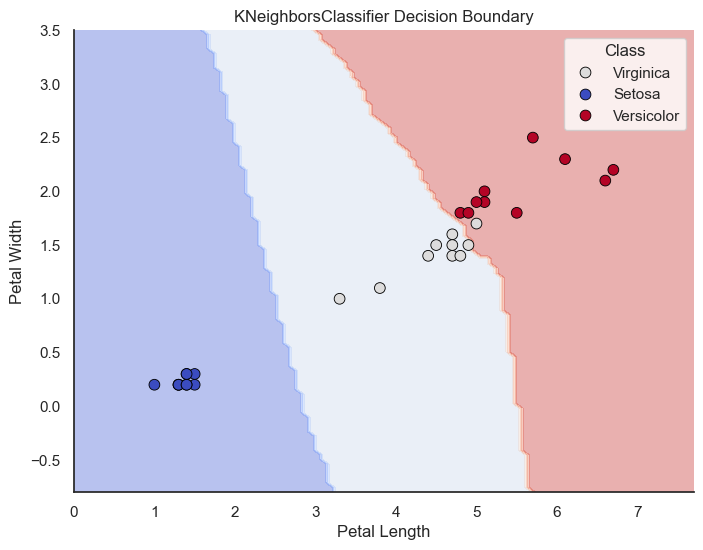

In [133]:
### Draw the decision boundary for the trained classifier
DrawDecisionBoundary(clf_knn.best_estimator_, X_test, y_test)

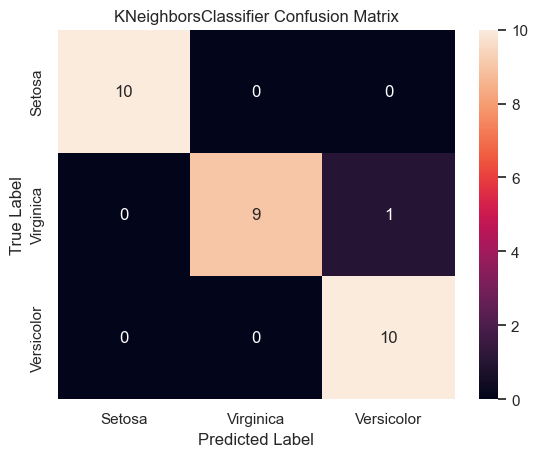

In [134]:
### Plot confusion matrix for the trained classifier
ConfusionMatrix(clf_knn.best_estimator_, X_test, y_test)

### 4.2.2. SVC

In [135]:
### Define pipeline. Includes scaling and model training
pipe_svm = Pipeline([
        ('scaler', 'passthrough'),
        ('model', SVC())
    ])

### Parameter grid to be used in RandomizedSearchCV
coarse_param_grid_svm= [
        {'scaler':scalers,
        'model__kernel':['linear'],                   #Linear kernel
        'model__C':np.logspace(-4,4,100)},

        {'scaler': scalers,
        'model__kernel':['rbf'],                      #RBF kernel
        'model__C':np.logspace(-4,4,100),
        'model__gamma':np.logspace(-5, 1, 50)},

        {'scaler':scalers,
        'model__kernel':['poly'],                     #Polynomial kernel
        'model__C':np.logspace(-4,4,100),
        'model__gamma':np.logspace(-5, 1, 50),
        'model__degree':[1,2,3,4,5]}  

    ]

For this model we first perform a randomized parameter grid search to roughly approximate hyperparameters. Next we apply a more focused search to refine the optimal values.
Additionally to data scaling, SVC uses a kernel to perform classification. Each kernel admits its own internal hyperparameters which are tuned.

In [136]:
### Model training on coarse parameters
start_time = time.time()
coarse_clf_svm = RandomizedSearchCV(pipe_svm, coarse_param_grid_svm, n_iter = 50, n_jobs = -1, cv = 10, random_state = 42, verbose = 1)
coarse_clf_svm.fit(X_train, y_train)
print(f'Training took {time.time()-start_time:.2f} seconds')


Fitting 10 folds for each of 50 candidates, totalling 500 fits
Training took 2.75 seconds


In [137]:
### Reinitialize parameter grid for fine tuning
param_grid_svm = {}

### Access best parameters of randomized search
best_C = coarse_clf_svm.best_params_['model__C']
param_grid_svm['model__C'] = np.linspace(best_C/5,best_C*5,10)

if not coarse_clf_svm.best_params_['model__kernel'] == 'linear':
    best_gamma = coarse_clf_svm.best_params_['model__gamma']
    param_grid_svm['model__gamma'] = np.linspace(best_gamma/5,best_gamma*5,10)

In [138]:
### Reinitialize pipeline with new parameters
pipe_svm = Pipeline([
        ('scaler',  coarse_clf_svm.best_params_['scaler']),
        ('model', SVC(kernel = coarse_clf_svm.best_params_['model__kernel']))
    ])

### Model training on final parameters
start_time = time.time()
clf_svm = GridSearchCV(pipe_svm, param_grid_svm, n_jobs=-1, cv = 10,verbose = 1)
clf_svm.fit(X_train, y_train)
print(f'Training took {time.time()-start_time:.2f} seconds')

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Training took 6.15 seconds


In [139]:
### Results of GridSearchCV on a readable dataframe
results_svm = pd.DataFrame(clf_svm.cv_results_)
results_svm = results_svm[
        [
            'param_model__C',
            'param_model__gamma',
            'mean_test_score',
            'std_test_score',
            'rank_test_score'
        ]
    ].sort_values('rank_test_score')


print(results_svm)

    param_model__C  param_model__gamma  mean_test_score  std_test_score  \
0         0.000024            0.277899         0.958333        0.055902   
1         0.000024            1.018963         0.958333        0.055902   
2         0.000024            1.760028         0.958333        0.055902   
3         0.000024            2.501092         0.958333        0.055902   
4         0.000024            3.242156         0.958333        0.055902   
..             ...                 ...              ...             ...   
68        0.000410            6.206413         0.950000        0.076376   
89        0.000538            6.947477         0.950000        0.076376   
88        0.000538            6.206413         0.950000        0.076376   
98        0.000602            6.206413         0.950000        0.076376   
99        0.000602            6.947477         0.950000        0.076376   

    rank_test_score  
0                 1  
1                 1  
2                 1  
3          

In [140]:
### Retrain model on complete training data and predict labels on test data
y_pred_svm = clf_svm.best_estimator_.predict(X_test)

### Add model's metrics to dataframe
name = clf_svm.best_estimator_.steps[-1][1].__class__.__name__
cv_accuracy = f"{clf_svm.best_score_:.2f}\u00B1{clf_svm.cv_results_['std_test_score'][clf_svm.best_index_]:.2f}"
accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm, average = 'weighted')
f1 = f1_score(y_test, y_pred_svm, average = 'weighted')
recall = recall_score(y_test, y_pred_svm, average = 'weighted')
scores.loc[len(scores)] = [name, cv_accuracy, accuracy, precision, f1, recall]

### Display evaluation metrics
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Test Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



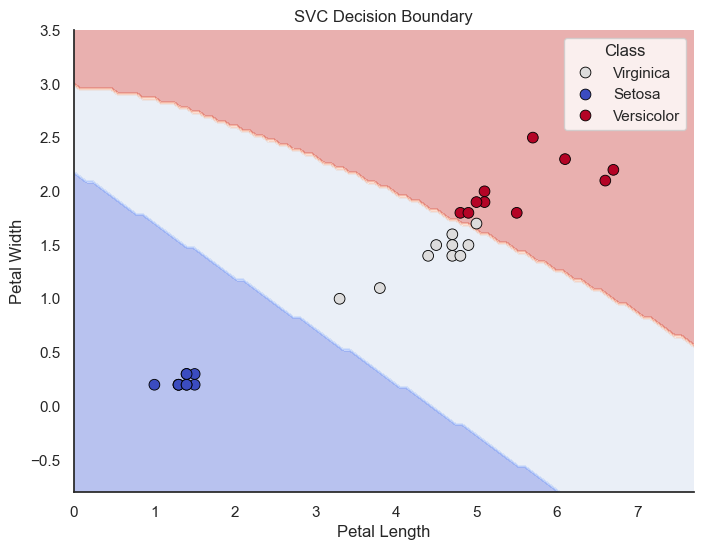

In [141]:
### Draw the decision boundary for the trained classifier
DrawDecisionBoundary(clf_svm.best_estimator_, X_test, y_test)

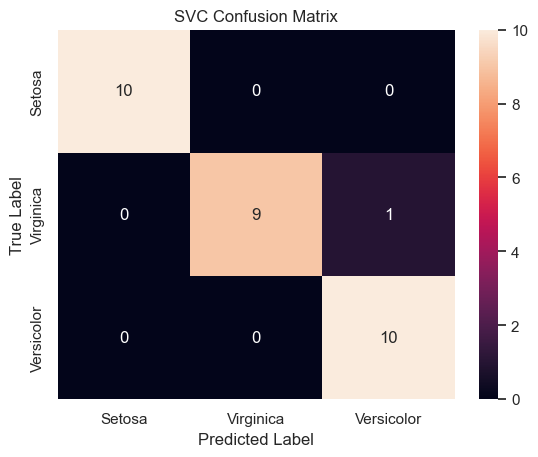

In [142]:
### Plot confusion matrix for the trained classifier
ConfusionMatrix(clf_svm.best_estimator_, X_test, y_test)

### 4.2.3. LogisticRegression

In [143]:
### Define pipeline. Includes scaling and model training
pipe_logreg = Pipeline([
        ('scaler', 'passthrough'),
        ('model', LogisticRegression())
    ])

### Parameter grid to be used in RandomizedSearchCV
coarse_param_grid_logreg = {
        'scaler':scalers,
        'model__C':np.logspace(-4,4,100) 
        }

As in the SVC model, we apply a randomized search first to approach the optimal value of C and then close in with a more precise Grid search

In [144]:
### Model training on coarse parameters
start_time = time.time()
coarse_clf_logreg = RandomizedSearchCV(pipe_logreg, coarse_param_grid_logreg, n_iter = 50, n_jobs=-1, cv = 10, random_state = 42, verbose = 1)
coarse_clf_logreg.fit(X_train, y_train)
print(f'Training took {time.time()-start_time:.2f} seconds')

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Training took 3.73 seconds


In [145]:
### Reinitialize pipeline with new parameters
pipe_logreg = Pipeline([
        ('scaler',  coarse_clf_logreg.best_params_['scaler']),
        ('model', LogisticRegression())
    ])

param_grid_logreg = {'model__C':np.linspace(coarse_clf_logreg.best_params_['model__C']/5,coarse_clf_logreg.best_params_['model__C']*5,100)}

### Model training on final parameters
start_time = time.time()
clf_logreg = GridSearchCV(pipe_logreg, param_grid_logreg, n_jobs=-1, cv = 10,verbose = 1)
clf_logreg.fit(X_train, y_train)
print(f'Training took {time.time()-start_time:.2f} seconds')

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Training took 7.89 seconds


In [146]:
### Results of GridSearchCV on a readable dataframe
results_logreg = pd.DataFrame(clf_logreg.cv_results_)
results_logreg = results_logreg[
        [
            'param_model__C',
            'mean_test_score',
            'std_test_score',
            'rank_test_score'
        ]
    ].sort_values('rank_test_score')


print(results_logreg)

    param_model__C  mean_test_score  std_test_score  rank_test_score
15        0.062444         0.983333        0.033333                1
16        0.065709         0.983333        0.033333                1
14        0.059179         0.975000        0.038188                3
13        0.055914         0.975000        0.038188                3
19        0.075504         0.975000        0.053359                3
..             ...              ...             ...              ...
4         0.026528         0.925000        0.044876               96
3         0.023263         0.916667        0.052705               97
2         0.019998         0.900000        0.062361               98
1         0.016733         0.891667        0.065085               99
0         0.013468         0.875000        0.055902              100

[100 rows x 4 columns]


In [147]:
### Retrain model on complete training data and predict labels on test data
y_pred_logreg = clf_logreg.best_estimator_.predict(X_test)

### Add model's metrics to dataframe
name = clf_logreg.best_estimator_.steps[-1][1].__class__.__name__
cv_accuracy = f"{clf_logreg.best_score_:.2f}\u00B1{clf_logreg.cv_results_['std_test_score'][clf_logreg.best_index_]:.2f}"
accuracy = accuracy_score(y_test, y_pred_logreg)
precision = precision_score(y_test, y_pred_logreg, average = 'weighted')
f1 = f1_score(y_test, y_pred_logreg, average = 'weighted')
recall = recall_score(y_test, y_pred_logreg, average = 'weighted')
scores.loc[len(scores)] = [name, cv_accuracy, accuracy, precision, f1, recall]

### Display evaluation metrics
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))

Test Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.80      0.89        10
           2       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



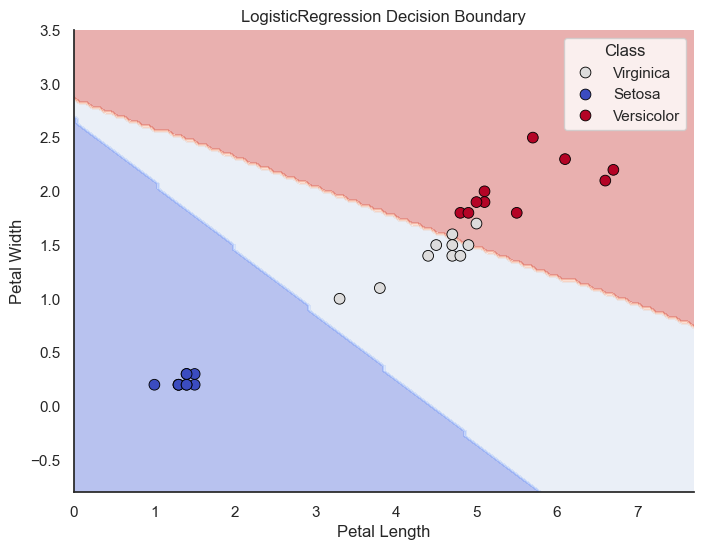

In [148]:
### Draw the decision boundary for the trained classifier
DrawDecisionBoundary(clf_logreg.best_estimator_, X_test, y_test)

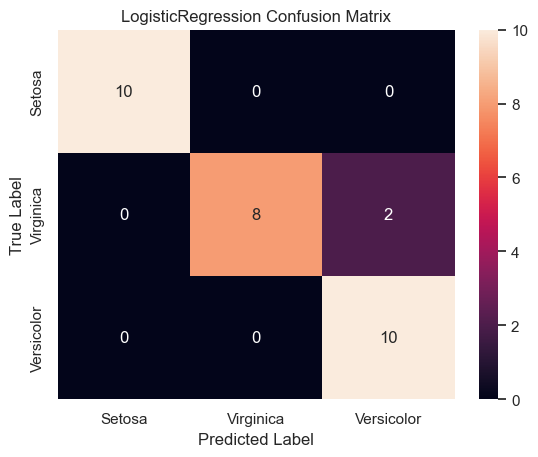

In [149]:
### Plot confusion matrix for the trained classifier
ConfusionMatrix(clf_logreg.best_estimator_, X_test, y_test)

### 4.2.4. RandomForestClassifier

In [150]:
### Define pipeline, includes only training
pipe_rf = Pipeline([
        ('model', RandomForestClassifier(random_state=42))
    ])

### Parameter grid to be used in RandomizedSearchCV
param_grid_rf = {
        "model__n_estimators": np.arange(200, 1000, 100),
        "model__max_depth": [None] + list(np.arange(2, 30)),
        "model__min_samples_split": np.arange(2, 30),
        "model__min_samples_leaf": np.arange(1, 30),
        "model__max_features": ["sqrt", "log2", None]
    }

In random forests randomized grid search is already effective in pinpointing optimal hyperparameters, hence a grid search is not required. Hyperparameters include number of trees in random forest, maximum depth of each tree, minimum samples required to split a node, minimum samples required at a leaf node, number of features considered at each split

In [151]:
### Model training
start_time = time.time()
clf_rf = RandomizedSearchCV(pipe_rf, param_grid_rf, n_iter = 60, n_jobs=-1, cv = 6, random_state = 42, verbose = 1)
clf_rf.fit(X_train, y_train)
print(f'Training took {time.time()-start_time:.2f} seconds')

Fitting 6 folds for each of 60 candidates, totalling 360 fits
Training took 303.88 seconds


In [152]:
### Results of RandomizedSearchCV on a readable dataframe
results_rf = pd.DataFrame(clf_rf.cv_results_)
results_rf = results_rf[
        [
            'param_model__n_estimators',
            'param_model__min_samples_split',
            'param_model__min_samples_leaf',
            'param_model__max_features',
            'param_model__max_depth',
            'mean_test_score',
            'std_test_score',
            'rank_test_score'
        ]
    ].sort_values('rank_test_score')
    

print(results_rf)

    param_model__n_estimators  param_model__min_samples_split  \
6                         300                               5   
13                        700                              12   
15                        900                              28   
8                         400                              19   
12                        400                              14   
21                        500                              27   
19                        600                              20   
17                        300                              18   
27                        400                              21   
31                        800                              15   
30                        500                              25   
38                        400                               6   
36                        500                              16   
35                        800                               8   
34                       

In [153]:
### Retrain model on complete training data and predict labels on test data
y_pred_rf = clf_rf.best_estimator_.predict(X_test)

### Add model's metrics to dataframe
name = clf_rf.best_estimator_.steps[-1][1].__class__.__name__
cv_accuracy = f"{clf_rf.best_score_:.2f}\u00B1{clf_rf.cv_results_['std_test_score'][clf_rf.best_index_]:.2f}"
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average = 'weighted')
f1 = f1_score(y_test, y_pred_rf, average = 'weighted')
recall = recall_score(y_test, y_pred_rf, average = 'weighted')
scores.loc[len(scores)] = [name, cv_accuracy, accuracy, precision, f1, recall]

### Display evaluation metrics
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Test Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.80      0.89        10
           2       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



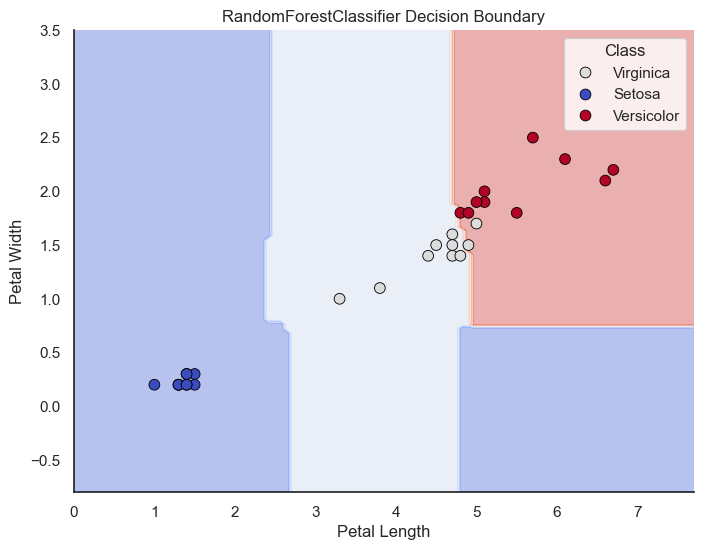

In [154]:
### Draw the decision boundary for the trained classifier
DrawDecisionBoundary(clf_rf.best_estimator_, X_test, y_test)

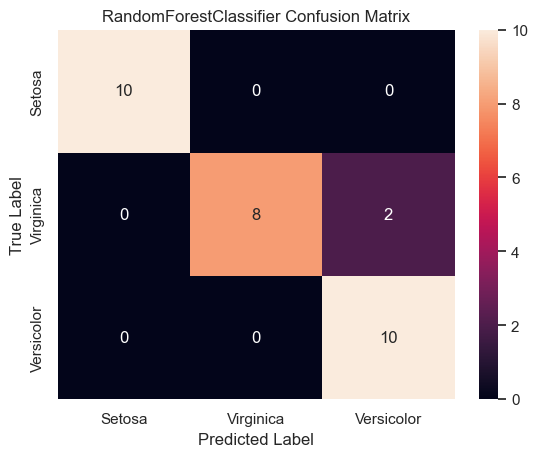

In [155]:
### Plot confusion matrix for the trained classifier
ConfusionMatrix(clf_rf.best_estimator_, X_test, y_test)

### 4.2.5. MLPClassifier

In [156]:
### Define pipeline. Includes scaling and model training
pipe_mlp = Pipeline([
        ('scaler', prep.StandardScaler()),
        ('model', MLPClassifier(hidden_layer_sizes=(50,),
                                solver = 'lbfgs',
                                random_state = 123,
                                max_iter=1000))
    ])

### Parameter grid to be used in GridsearchCV
param_grid_mlp = {
        'scaler': [prep.StandardScaler(),prep.MinMaxScaler(),prep.RobustScaler()],
        'model__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    }

The hyperparameters to be tuned are the hidden layers of the neural network. Scaling is not optional when training a neural network.

In [157]:
### Model training
start_time = time.time()
clf_mlp = GridSearchCV(pipe_mlp, param_grid_mlp, n_jobs=-1, cv = 10,verbose = 1)
clf_mlp.fit(X_train, y_train)
print(f'Training took {time.time()-start_time:.2f} seconds')

Fitting 10 folds for each of 9 candidates, totalling 90 fits
Training took 8.63 seconds


In [158]:
### Results of GridSearchCV on a readable dataframe
results_mlp = pd.DataFrame(clf_mlp.cv_results_)
results_mlp = results_mlp[
        [
            'param_model__hidden_layer_sizes',
            'param_scaler',
            'mean_test_score',
            'std_test_score',
            'rank_test_score'
        ]
    ].sort_values('rank_test_score')
    
print(results_mlp)

  param_model__hidden_layer_sizes      param_scaler  mean_test_score  \
5                          (100,)    RobustScaler()         0.975000   
2                           (50,)    RobustScaler()         0.966667   
4                          (100,)    MinMaxScaler()         0.958333   
1                           (50,)    MinMaxScaler()         0.958333   
6                        (50, 50)  StandardScaler()         0.958333   
8                        (50, 50)    RobustScaler()         0.958333   
7                        (50, 50)    MinMaxScaler()         0.950000   
3                          (100,)  StandardScaler()         0.941667   
0                           (50,)  StandardScaler()         0.941667   

   std_test_score  rank_test_score  
5        0.038188                1  
2        0.055277                2  
4        0.055902                3  
1        0.055902                3  
6        0.055902                3  
8        0.055902                3  
7        0.055277   

In [159]:
### Retrain model on complete training data and predict labels on test data
y_pred_mlp = clf_mlp.best_estimator_.predict(X_test)

### Add model's metrics to dataframe
name = clf_mlp.best_estimator_.steps[-1][1].__class__.__name__
cv_accuracy = f"{clf_mlp.best_score_:.2f}\u00B1{clf_mlp.cv_results_['std_test_score'][clf_mlp.best_index_]:.2f}"
accuracy = accuracy_score(y_test, y_pred_mlp)
precision = precision_score(y_test, y_pred_mlp, average = 'weighted')
f1 = f1_score(y_test, y_pred_mlp, average = 'weighted')
recall = recall_score(y_test, y_pred_mlp, average = 'weighted')
scores.loc[len(scores)] = [name, cv_accuracy, accuracy, precision, f1, recall]

### Display evaluation metrics
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))

Test Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



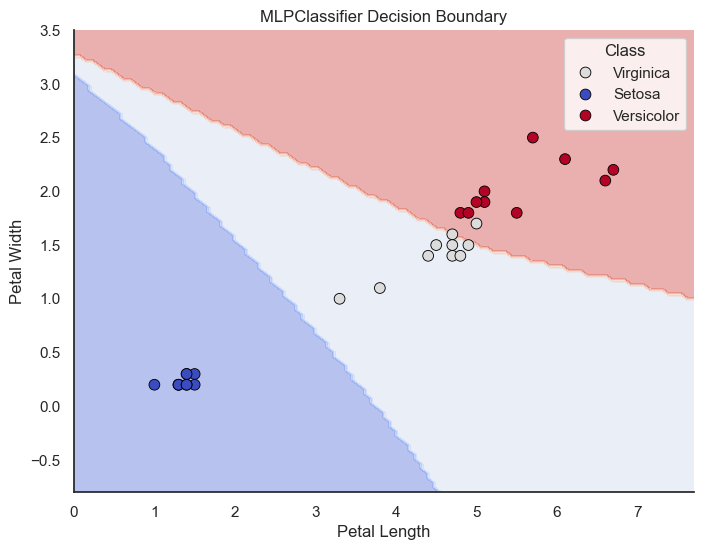

In [160]:
### Draw the decision boundary for the trained classifier
DrawDecisionBoundary(clf_mlp.best_estimator_, X_test, y_test)

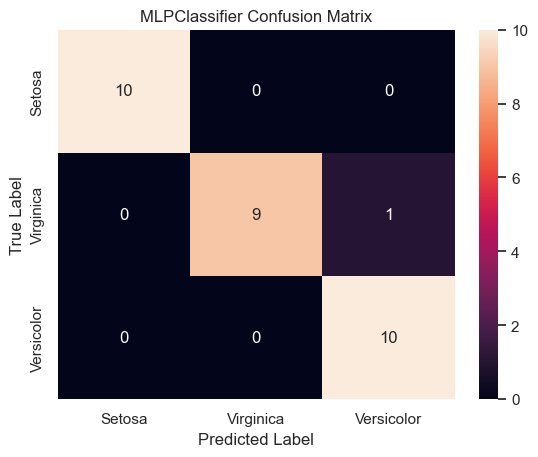

In [161]:
### Plot confusion matrix for the trained classifier
ConfusionMatrix(clf_mlp.best_estimator_, X_test, y_test)

### 4.2.6. XGBClassifier

In [162]:
### Define pipeline, includes only training
pipe_xgb = Pipeline([
        ('model', XGBClassifier(
            objective='multi:softprob',
            eval_metric='mlogloss',
            random_state=123))
    ])

### Parameter grid to be used in GridsearchCV
param_grid_xgb = {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.1, 0.2],
    }

Hyperparameters to be tuned include number of boosting rounds, maximum depth of each tree and step size shrinkage 

In [163]:
### Model training
start_time = time.time()
clf_xgb = GridSearchCV(pipe_xgb, param_grid_xgb, n_jobs=-1, cv = 10,verbose = 1)
clf_xgb.fit(X_train, y_train)
print(f'Training took {time.time()-start_time:.2f} seconds')

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Training took 9.99 seconds


In [164]:
### Results of GridSearchCV on a readable dataframe
results_xgb = pd.DataFrame(clf_xgb.cv_results_)
results_xgb = results_xgb[
        [
            'param_model__n_estimators',
            'param_model__max_depth',
            'param_model__learning_rate',
            'mean_test_score',
            'std_test_score',
            'rank_test_score'
        ]
    ].sort_values('rank_test_score')
    
print(results_xgb)

    param_model__n_estimators  param_model__max_depth  \
12                         50                       5   
15                         50                       7   
9                          50                       3   
0                          50                       3   
4                         100                       5   
1                         100                       3   
2                         200                       3   
3                          50                       5   
7                         100                       7   
6                          50                       7   
5                         200                       5   
8                         200                       7   
11                        200                       3   
10                        100                       3   
13                        100                       5   
14                        200                       5   
16                        100  

In [165]:
### Retrain model on complete training data and predict labels on test data
y_pred_xgb = clf_xgb.best_estimator_.predict(X_test)

### Add model's metrics to dataframe
name = clf_xgb.best_estimator_.steps[-1][1].__class__.__name__
cv_accuracy = f"{clf_xgb.best_score_:.2f}\u00B1{clf_xgb.cv_results_['std_test_score'][clf_xgb.best_index_]:.2f}"
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average = 'weighted')
f1 = f1_score(y_test, y_pred_xgb, average = 'weighted')
recall = recall_score(y_test, y_pred_xgb, average = 'weighted')
scores.loc[len(scores)] = [name, cv_accuracy, accuracy, precision, f1, recall]

### Display evaluation metrics
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Test Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



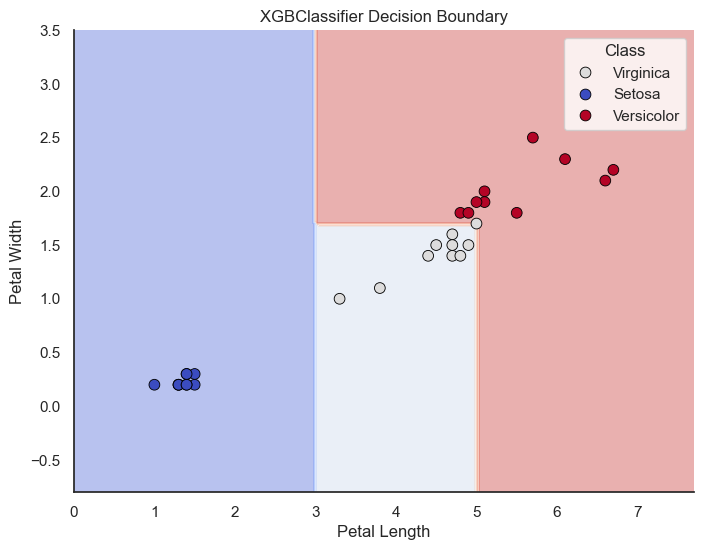

In [166]:
### Draw the decision boundary for the trained classifier
DrawDecisionBoundary(clf_xgb.best_estimator_, X_test, y_test)

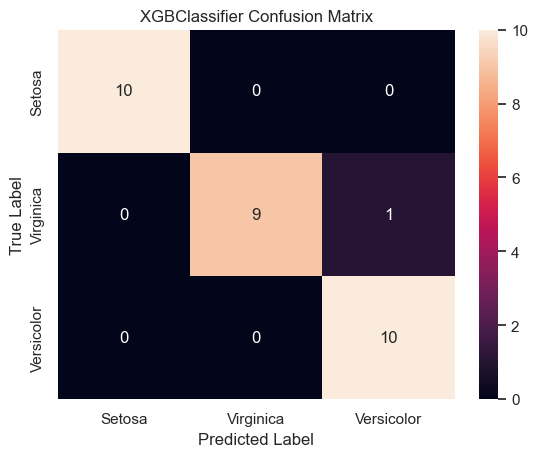

In [167]:
### Plot confusion matrix for the trained classifier
ConfusionMatrix(clf_xgb.best_estimator_, X_test, y_test)

## 5. Evaluation

In this final section we review our results and draw our final conclusions. In the following table we present the evaluation metrics for each model. The order in which they are presented is from highest to lowest Accuracy. The first column, CV Accuracy, represents the average accuracy of the model during cross validation, which is performed on the training set. The rest of the metrics are calculated from the predictions of each model. 

In [168]:
scores_sorted = scores.sort_values(by='Accuracy', ascending=False)
print(scores_sorted)

                          Model     CV Accuracy  Accuracy  Precision  \
1          KNeighborsClassifier       0.97±0.06  0.966667   0.969697   
2                           SVC       0.96±0.06  0.966667   0.969697   
6                 XGBClassifier       0.96±0.06  0.966667   0.969697   
5                 MLPClassifier       0.97±0.04  0.966667   0.969697   
4        RandomForestClassifier       0.97±0.02  0.933333   0.944444   
3            LogisticRegression       0.98±0.03  0.933333   0.944444   
0  DummyClassifier (stratified)  Not Applicable  0.233333   0.223485   

   F1 score    Recall  
1  0.966583  0.966667  
2  0.966583  0.966667  
6  0.966583  0.966667  
5  0.966583  0.966667  
4  0.932660  0.933333  
3  0.932660  0.933333  
0  0.227513  0.233333  


The close agreement between cross-validation accuracy and test accuracy across all models suggests that overfitting is minimal. This is expected due to the simplicity and small size of the dataset.

Although several models achieve identical test performance, their complexity differs significantly. Simpler models such as Logistic Regression and KNN achieve comparable results to more complex models like XGBoost and MLP, indicating that the dataset is linearly (or near-linearly) separable.

The dummy classifier achieves significantly lower performance (approximately 33% accuracy), confirming that all trained models successfully learn meaningful patterns from the data and substantially outperform random guessing.

The accuracies and precisions of the other models models lie within the estimated intervals posted on [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/53/iris), which suggest our analysis is consistent with previous work on the subject. 

The decision boundary plots confirm that Iris Setosa is linearly separable from the other classes, while the boundary between Versicolor and Virginica is more complex and accounts for all observed misclassifications.

This analysis is limited by the small size and simplicity of the Iris dataset. As a result, differences between models are minimal.

Overall, this study demonstrates that for simple, well-structured datasets, model selection is less critical than proper preprocessing and evaluation methodology.